In [ ]:
!pip install timm -q

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import timm
import pandas as pd
import numpy as np
import json
import os
import random
from PIL import Image, ImageEnhance
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, roc_auc_score,
    f1_score, accuracy_score,
    mean_absolute_error, mean_squared_error
)
from google.colab import drive

drive.mount('/content/drive')

BASE          = '/content/drive/MyDrive/CDT_Dataset'
HUMAN_FOLDER  = f'{BASE}/images_human_fixed'
RESULT_FOLDER = f'{BASE}/results'
MODEL_FOLDER  = f'{BASE}/models_human'

os.makedirs(RESULT_FOLDER, exist_ok=True)
os.makedirs(MODEL_FOLDER,  exist_ok=True)

device = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)
CUTOFF = 6
print(f'Device: {device}')

Mounted at /content/drive
Device: cuda


In [ ]:
train_df = pd.read_csv(
    f'{BASE}/labels/human_train.csv'
)
val_df   = pd.read_csv(
    f'{BASE}/labels/human_val.csv'
)
test_df  = pd.read_csv(
    f'{BASE}/labels/human_test.csv'
)

for d in [train_df, val_df, test_df]:
    d['dementia_risk'] = d['dementia_risk'].astype(bool)

print(f'Train: {len(train_df)} รูป')
print(f'  Normal  : {(~train_df["dementia_risk"]).sum()}')
print(f'  Dementia: {train_df["dementia_risk"].sum()}')
print(f'Val  : {len(val_df)} รูป')
print(f'Test : {len(test_df)} รูป')

TARGET_DEMENTIA = 1200
AUG_FOLDER = f'{BASE}/images_human_aug'
os.makedirs(AUG_FOLDER, exist_ok=True)

dementia_df = train_df[train_df['dementia_risk']]
normal_df   = train_df[~train_df['dementia_risk']]
current_dem = len(dementia_df)
need_more   = max(0, TARGET_DEMENTIA - current_dem)

print(f'\nAugmentation plan:')
print(f'  Dementia ตอนนี้: {current_dem} รูป')
print(f'  Target          : {TARGET_DEMENTIA} รูป')
print(f'  เพิ่ม       : {need_more} รูป')

def augment_image_no_rotation(img):
    """Augment โดยไม่หมุนเลย"""
    # brightness
    factor = random.uniform(0.8, 1.2)
    img    = ImageEnhance.Brightness(img).enhance(factor)
    # contrast
    factor = random.uniform(0.8, 1.2)
    img    = ImageEnhance.Contrast(img).enhance(factor)
    # zoom
    zoom  = random.uniform(0.9, 1.1)
    w, h  = img.size
    new_w = int(w * zoom)
    new_h = int(h * zoom)
    img   = img.resize((new_w, new_h), Image.LANCZOS)
    left  = max(0, (new_w - w) // 2)
    top   = max(0, (new_h - h) // 2)
    img   = img.crop((left, top,
                      left + min(w, new_w),
                      top  + min(h, new_h)))
    img   = img.resize((w, h), Image.LANCZOS)
    return img

aug_rows  = []
generated = 0

if need_more > 0:
    print('\nกำลัง augment...')
    while generated < need_more:
        for _, row in dementia_df.iterrows():
            if generated >= need_more:
                break
            try:
                src = f'{HUMAN_FOLDER}/{row["filename"]}'
                img = Image.open(src).convert('RGB')
                aug = augment_image_no_rotation(img)

                new_name = (
                    f'aug_{generated:05d}_{row["filename"]}'
                )
                aug.save(
                    f'{AUG_FOLDER}/{new_name}',
                    'JPEG', quality=95
                )

                new_row             = row.copy()
                new_row['filename'] = new_name
                aug_rows.append(new_row)
                generated += 1

            except Exception as e:
                continue

    aug_df   = pd.DataFrame(aug_rows)
    train_df = pd.concat(
        [train_df, aug_df], ignore_index=True
    ).sample(frac=1, random_state=42).reset_index(
        drop=True
    )
    print(f'Augment เสร็จ: {generated} รูป')

print(f'\nTrain set หลัง augment:')
print(f'  Normal  : {(~train_df["dementia_risk"]).sum()}')
print(f'  Dementia: {train_df["dementia_risk"].sum()}')
print(f'  Total   : {len(train_df)}')

Train: 4621 รูป
  Normal  : 3839
  Dementia: 782
Val  : 653 รูป
Test : 1328 รูป

Augmentation plan:
  Dementia ตอนนี้: 782 รูป
  Target          : 1200 รูป
  เพิ่ม       : 418 รูป

กำลัง augment...
Augment เสร็จ: 418 รูป

Train set หลัง augment:
  Normal  : 3839
  Dementia: 1200
  Total   : 5039


In [ ]:
class CDTDataset(Dataset):
    def __init__(self, df, human_folder,
                 aug_folder=None, transform=None):
        self.df           = df.reset_index(drop=True)
        self.human_folder = human_folder
        self.aug_folder   = aug_folder
        self.transform    = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        filename = row['filename']

        if (self.aug_folder and
                filename.startswith('aug_')):
            img_path = f'{self.aug_folder}/{filename}'
        else:
            img_path = f'{self.human_folder}/{filename}'

        try:
            img = Image.open(img_path).convert('RGB')
        except:
            img = Image.new('RGB', (224, 224),
                           (255, 255, 255))

        if self.transform:
            img = self.transform(img)

        labels = torch.tensor([
            row['domain_A'], row['domain_B'],
            row['domain_C'], row['domain_D'],
            row['domain_E']
        ], dtype=torch.float32)

        return img, labels

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ColorJitter(
        brightness=0.2, contrast=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )
])

In [ ]:
class CDTModel(nn.Module):
    def __init__(self, backbone_name='resnet50',
                 num_domains=5, num_classes=3):
        super().__init__()

        if backbone_name == 'resnet50':
            backbone = models.resnet50(
                weights=models.ResNet50_Weights.IMAGENET1K_V1
            )
            self.feature_dim = 2048
            for param in backbone.parameters():
                param.requires_grad = False
            self.backbone = nn.Sequential(
                *list(backbone.children())[:-1]
            )

        elif backbone_name == 'vit':
            self.backbone = timm.create_model(
                'vit_base_patch16_224',
                pretrained=True,
                num_classes=0
            )
            self.feature_dim = 768
            for param in self.backbone.parameters():
                param.requires_grad = False

        self.backbone_name = backbone_name
        self.shared = nn.Sequential(
            nn.Flatten(),
            nn.Linear(self.feature_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.3)
        )
        self.heads_cls = nn.ModuleList([
            nn.Linear(512, num_classes)
            for _ in range(num_domains)
        ])
        self.heads_reg = nn.ModuleList([
            nn.Linear(512, 1)
            for _ in range(num_domains)
        ])

    def forward(self, x, mode='reg'):
        if self.backbone_name == 'resnet50':
            feat = self.backbone(x)
        else:
            feat = self.backbone(x)
            feat = feat.unsqueeze(-1).unsqueeze(-1)
        feat = self.shared(feat)
        if mode == 'reg':
            return [head(feat).squeeze(-1)
                    for head in self.heads_reg]
        else:
            return [head(feat)
                    for head in self.heads_cls]

In [ ]:
DOMAIN_WEIGHTS = torch.tensor(
    [1.0, 1.5, 1.0, 1.0, 1.0]
).to(device)

def compute_loss(outputs, labels, mode='reg'):
    total_loss = 0
    for i, output in enumerate(outputs):
        if mode == 'reg':
            loss = nn.MSELoss()(
                output, labels[:, i].float()
            )
        else:
            loss = nn.CrossEntropyLoss()(
                output, labels[:, i].long()
            )
        total_loss += loss * DOMAIN_WEIGHTS[i]
    return total_loss / DOMAIN_WEIGHTS.sum()

def get_predictions(outputs, mode='reg'):
    preds = []
    for output in outputs:
        if mode == 'reg':
            pred = output.round().clamp(0, 2).long()
        else:
            pred = output.argmax(dim=1)
        preds.append(pred)
    return torch.stack(preds, dim=1)

def evaluate_model(model, loader, mode='reg'):
    model.eval()
    all_preds  = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images  = images.to(device)
            outputs = model(images, mode=mode)
            preds   = get_predictions(outputs, mode)
            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())

    all_preds  = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    pred_total    = all_preds.sum(axis=1)
    true_total    = all_labels.sum(axis=1)
    pred_dementia = (pred_total < CUTOFF).astype(int)
    true_dementia = (true_total < CUTOFF).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        true_dementia, pred_dementia, labels=[0,1]
    ).ravel()

    sens = tp/(tp+fn) if (tp+fn) > 0 else 0
    spec = tn/(tn+fp) if (tn+fp) > 0 else 0
    try:
        auc = roc_auc_score(true_dementia, -pred_total)
    except:
        auc = 0

    domain_metrics = {}
    for i, d in enumerate(['A','B','C','D','E']):
        domain_metrics[d] = {
            'acc': accuracy_score(
                all_labels[:,i], all_preds[:,i]),
            'mae': mean_absolute_error(
                all_labels[:,i], all_preds[:,i]),
            'mse': mean_squared_error(
                all_labels[:,i], all_preds[:,i]),
            'f1' : f1_score(
                all_labels[:,i], all_preds[:,i],
                average='macro', zero_division=0),
        }

    return {
        'sensitivity'   : sens,
        'specificity'   : spec,
        'auc'           : auc,
        'f1'            : f1_score(
            true_dementia, pred_dementia,
            zero_division=0),
        'domain_metrics': domain_metrics,
        'avg_acc'       : np.mean([
            m['acc']
            for m in domain_metrics.values()]),
        'avg_mae'       : np.mean([
            m['mae']
            for m in domain_metrics.values()]),
        'pred_total'    : pred_total,
        'true_total'    : true_total,
        'true_dementia' : true_dementia,
    }

In [ ]:
def train_model(backbone, mode,
                model_name,
                epochs=20, patience=10):

    print(f'\n{"="*60}')
    print(f'Training: {model_name}')
    print(f'Backbone: {backbone} | Loss: {mode}')
    print(f'Human Labels + No Rotation Augment')
    print(f'{"="*60}')

    train_ds = CDTDataset(
        train_df, HUMAN_FOLDER,
        AUG_FOLDER if need_more > 0 else None,
        train_transform
    )
    val_ds = CDTDataset(
        val_df, HUMAN_FOLDER, None, val_transform
    )
    test_ds = CDTDataset(
        test_df, HUMAN_FOLDER, None, val_transform
    )

    train_loader = DataLoader(
        train_ds, batch_size=16,
        shuffle=True, num_workers=2
    )
    val_loader = DataLoader(
        val_ds, batch_size=16,
        shuffle=False, num_workers=2
    )
    test_loader = DataLoader(
        test_ds, batch_size=16,
        shuffle=False, num_workers=2
    )

    model = CDTModel(backbone_name=backbone).to(device)

    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad,
               model.parameters()),
        lr=1e-3, weight_decay=1e-4
    )
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=3, factor=0.5
    )

    best_combined = -1
    best_state    = None
    no_improve    = 0
    history = {
        'train_loss': [], 'val_loss': [],
        'sensitivity': [], 'specificity': [],
        'auc': []
    }

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)
            optimizer.zero_grad()
            outputs = model(images, mode=mode)
            loss    = compute_loss(outputs, labels, mode)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)

        val_results = evaluate_model(
            model, val_loader, mode=mode
        )

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)
                outputs = model(images, mode=mode)
                loss    = compute_loss(
                    outputs, labels, mode
                )
                val_loss += loss.item()
        val_loss /= len(val_loader)

        scheduler.step(val_loss)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['sensitivity'].append(
            val_results['sensitivity'])
        history['specificity'].append(
            val_results['specificity'])
        history['auc'].append(val_results['auc'])

        combined = (val_results['sensitivity'] +
                    val_results['specificity']) / 2
        if combined > best_combined:
            best_combined = combined
            best_state    = {
                k: v.cpu().clone()
                for k, v in model.state_dict().items()
            }
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'Early stopping epoch {epoch+1}')
                break

        print(f'Epoch {epoch+1:2d}/{epochs} | '
              f'Loss: {train_loss:.4f}/{val_loss:.4f} | '
              f'Sens: {val_results["sensitivity"]:.3f} | '
              f'Spec: {val_results["specificity"]:.3f} | '
              f'AUC: {val_results["auc"]:.3f}')

    model.load_state_dict(best_state)
    torch.save(
        best_state,
        f'{MODEL_FOLDER}/{model_name}_best.pth'
    )
    with open(
        f'{RESULT_FOLDER}/history_{model_name}.json',
        'w'
    ) as f:
        json.dump(history, f)

    test_results = evaluate_model(
        model, test_loader, mode=mode
    )

    return model, history, test_results

In [ ]:
results_human = {}

for backbone, mode in [
    ('resnet50', 'reg'),
    ('resnet50', 'cls'),
    ('vit',      'reg'),
    ('vit',      'cls'),
]:
    epochs     = 15 if backbone == 'vit' else 20
    model_name = f'human_{backbone}_{mode}'
    path       = f'{MODEL_FOLDER}/{model_name}_best.pth'

    if os.path.exists(path):
        print(f'\nโหลด {model_name}')
        model = CDTModel(backbone_name=backbone).to(device)
        model.load_state_dict(
            torch.load(path, map_location=device)
        )
        model.eval()

        test_ds = CDTDataset(
            test_df, HUMAN_FOLDER,
            None, val_transform
        )
        test_loader = DataLoader(
            test_ds, batch_size=16, shuffle=False
        )
        test_results = evaluate_model(
            model, test_loader, mode=mode
        )
    else:
        _, _, test_results = train_model(
            backbone, mode,
            model_name,
            epochs=epochs, patience=10
        )

    results_human[f'{backbone}_{mode}'] = test_results

    print(f'\n{model_name}:')
    print(f'  Sensitivity : '
          f'{test_results["sensitivity"]:.3f} '
          f'{"✅" if test_results["sensitivity"]>=0.88 else "⚠️"}')
    print(f'  Specificity : '
          f'{test_results["specificity"]:.3f} '
          f'{"✅" if test_results["specificity"]>=0.82 else "⚠️"}')
    print(f'  AUC         : '
          f'{test_results["auc"]:.3f} '
          f'{"✅" if test_results["auc"]>=0.91 else "⚠️"}')
    print(f'  Avg Domain  : '
          f'{test_results["avg_acc"]:.3f}')


โหลด human_resnet50_reg
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 326MB/s]



human_resnet50_reg:
  Sensitivity : 0.827 ⚠️
  Specificity : 0.718 ⚠️
  AUC         : 0.845 ⚠️
  Avg Domain  : 0.531

โหลด human_resnet50_cls

human_resnet50_cls:
  Sensitivity : 0.578 ⚠️
  Specificity : 0.936 ✅
  AUC         : 0.859 ⚠️
  Avg Domain  : 0.748

โหลด human_vit_reg


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]


human_vit_reg:
  Sensitivity : 0.582 ⚠️
  Specificity : 0.922 ✅
  AUC         : 0.872 ⚠️
  Avg Domain  : 0.645

โหลด human_vit_cls

human_vit_cls:
  Sensitivity : 0.582 ⚠️
  Specificity : 0.958 ✅
  AUC         : 0.853 ⚠️
  Avg Domain  : 0.745


In [ ]:
print('='*60)
print('Cutoff Analysis — Human Labels')
print('='*60)

for key, results in results_human.items():
    pred_total    = results['pred_total']
    true_dementia = results['true_dementia']

    print(f'\n{key}:')
    print(f'{"Cutoff":>8} {"Sens":>8} '
          f'{"Spec":>8} {"AUC":>8}')
    print('-'*38)

    for cutoff in [5, 6, 7, 8]:
        pred = (pred_total < cutoff).astype(int)
        try:
            tn, fp, fn, tp = confusion_matrix(
                true_dementia, pred, labels=[0,1]
            ).ravel()
            sens = tp/(tp+fn) if (tp+fn) > 0 else 0
            spec = tn/(tn+fp) if (tn+fp) > 0 else 0
            auc  = roc_auc_score(
                true_dementia, -pred_total
            )
        except:
            sens, spec, auc = 0, 0, 0

        mark = '✅' if (sens >= 0.88 and
                       spec >= 0.82) else '⚠️'
        print(f'{cutoff:>8} {sens:>8.3f} '
              f'{spec:>8.3f} {auc:>8.3f} {mark}')

Cutoff Analysis — Human Labels

resnet50_reg:
  Cutoff     Sens     Spec      AUC
--------------------------------------
       5    0.369    0.976    0.845 ⚠️
       6    0.827    0.718    0.845 ⚠️
       7    0.858    0.694    0.845 ⚠️
       8    0.991    0.303    0.845 ⚠️

resnet50_cls:
  Cutoff     Sens     Spec      AUC
--------------------------------------
       5    0.449    0.973    0.859 ⚠️
       6    0.578    0.936    0.859 ⚠️
       7    0.636    0.911    0.859 ⚠️
       8    0.658    0.894    0.859 ⚠️

vit_reg:
  Cutoff     Sens     Spec      AUC
--------------------------------------
       5    0.307    0.989    0.872 ⚠️
       6    0.582    0.922    0.872 ⚠️
       7    0.658    0.897    0.872 ⚠️
       8    0.938    0.596    0.872 ⚠️

vit_cls:
  Cutoff     Sens     Spec      AUC
--------------------------------------
       5    0.476    0.982    0.853 ⚠️
       6    0.582    0.958    0.853 ⚠️
       7    0.689    0.904    0.853 ⚠️
       8    0.707    0.894    0.85

In [ ]:
llm_human_path = f'{RESULT_FOLDER}/baseline_llm_human.json'

if os.path.exists(llm_human_path):
    with open(llm_human_path) as f:
        llm_human = json.load(f)
else:
    print('ไม่พบ baseline_llm_human.json')
    llm_human = None

# ผล LLM baseline เดิม (LLM test)
llm_old_results = {
    'resnet50_reg': {
        'sensitivity': 0.886,
        'specificity': 0.616,
        'auc'        : 0.838
    },
    'resnet50_cls': {
        'sensitivity': 0.778,
        'specificity': 0.843,
        'auc'        : 0.870
    },
    'vit_reg': {
        'sensitivity': 0.719,
        'specificity': 0.875,
        'auc'        : 0.866
    },
    'vit_cls': {
        'sensitivity': 0.713,
        'specificity': 0.907,
        'auc'        : 0.859
    },
}

print('='*80)
print('COMPARISON: LLM Old → LLM Human → Human Model')
print('AUC = Primary Metric')
print('='*80)
print(f'{"Model":<20} {"LLM(LLM test)":>14} '
      f'{"LLM(Human test)":>16} '
      f'{"Human Model":>13} {"Best":>10}')
print(f'{"":20} {"AUC":>14} '
      f'{"AUC":>16} {"AUC":>13}')
print('='*80)

for key in llm_old_results:
    old_auc   = llm_old_results[key]['auc']
    llm_h_auc = llm_human['auc_roc'] \
                if llm_human else 0
    hum_auc   = results_human.get(
        key, {}
    ).get('auc', 0)

    best_auc = max(old_auc, llm_h_auc, hum_auc)
    best = {
        old_auc  : 'LLM(old)',
        llm_h_auc: 'LLM(human)',
        hum_auc  : 'Human Model',
    }[best_auc]

    h_m = '✅' if hum_auc > old_auc else '⚠️'

    print(f'{key:<20} {old_auc:>14.3f} '
          f'{llm_h_auc:>16.3f} '
          f'{hum_auc:>12.3f}{h_m} '
          f'{best:>10}')

print('='*80)

print(f'\nSensitivity/Specificity (cutoff=6):')
print(f'{"Model":<20} {"LLM(old)":>14} '
      f'{"LLM(human)":>14} {"Human Model":>14}')
print('-'*65)

llm_h_str = (
    f'{llm_human["sensitivity"]:.3f}/'
    f'{llm_human["specificity"]:.3f}'
    if llm_human else 'N/A'
)

for key in llm_old_results:
    o = llm_old_results[key]
    h = results_human.get(key, {})

    o_str = (f'{o["sensitivity"]:.3f}/'
             f'{o["specificity"]:.3f}')
    h_str = (
        f'{h["sensitivity"]:.3f}/'
        f'{h["specificity"]:.3f}'
        if h else 'N/A'
    )

    h_pass = '✅' if h and (
        h['sensitivity'] >= 0.88 and
        h['specificity'] >= 0.82
    ) else ''

    print(f'{key:<20} {o_str:>14} '
          f'{llm_h_str:>14} '
          f'{h_str:>13}{h_pass}')

print('-'*65)
print(f'{"Target":<20} {"≥0.880/≥0.820":>14}')

with open(
    f'{RESULT_FOLDER}/07j_human_results.json', 'w'
) as f:
    json.dump({
        'llm_baseline_old'  : llm_old_results,
        'llm_baseline_human': llm_human,
        'human_models'      : {
            k: {
                'sensitivity': float(v['sensitivity']),
                'specificity': float(v['specificity']),
                'auc'        : float(v['auc']),
                'avg_acc'    : float(v['avg_acc']),
            }
            for k, v in results_human.items()
        }
    }, f, indent=2, ensure_ascii=False)

COMPARISON: LLM Old → LLM Human → Human Model
AUC = Primary Metric
Model                 LLM(LLM test)  LLM(Human test)   Human Model       Best
                                AUC              AUC           AUC
resnet50_reg                  0.838            0.873        0.845✅ LLM(human)
resnet50_cls                  0.870            0.873        0.859⚠️ LLM(human)
vit_reg                       0.866            0.873        0.872✅ LLM(human)
vit_cls                       0.859            0.873        0.853⚠️ LLM(human)

Sensitivity/Specificity (cutoff=6):
Model                      LLM(old)     LLM(human)    Human Model
-----------------------------------------------------------------
resnet50_reg            0.886/0.616    0.711/0.925   0.827/0.718
resnet50_cls            0.778/0.843    0.711/0.925   0.578/0.936
vit_reg                 0.719/0.875    0.711/0.925   0.582/0.922
vit_cls                 0.713/0.907    0.711/0.925   0.582/0.958
---------------------------------------------

In [ ]:
llm_results = llm_old_results

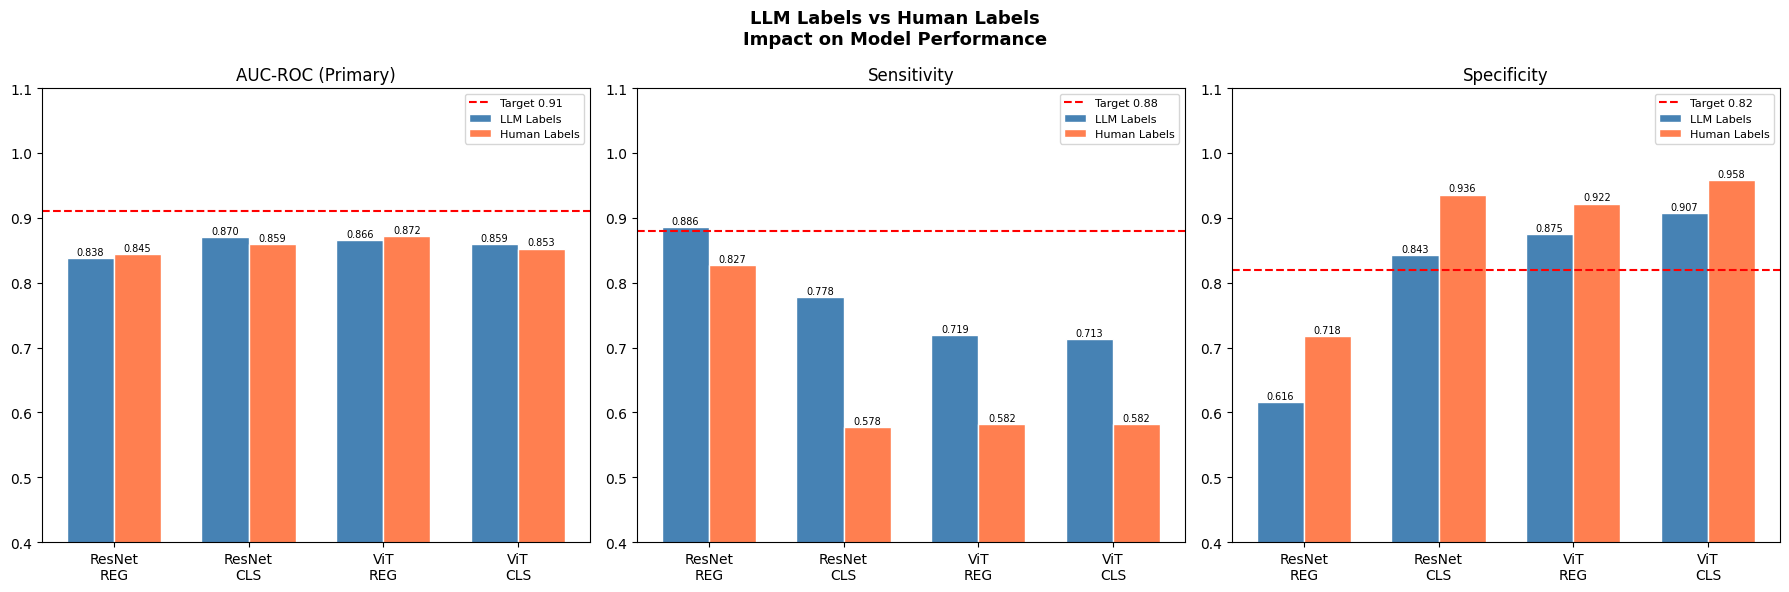

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

model_keys  = list(llm_results.keys())
short_names = ['ResNet\nREG', 'ResNet\nCLS',
               'ViT\nREG',   'ViT\nCLS']
x     = np.arange(len(model_keys))
width = 0.35

for ax_idx, (metric, title, target) in enumerate([
    ('auc',         'AUC-ROC (Primary)', 0.91),
    ('sensitivity', 'Sensitivity',       0.88),
    ('specificity', 'Specificity',       0.82),
]):
    llm_vals   = [llm_results[k][metric]
                  for k in model_keys]
    human_vals = [
        results_human.get(k, {}).get(metric, 0)
        for k in model_keys
    ]

    bars_l = axes[ax_idx].bar(
        x - width/2, llm_vals, width,
        label='LLM Labels',
        color='steelblue', edgecolor='white'
    )
    bars_h = axes[ax_idx].bar(
        x + width/2, human_vals, width,
        label='Human Labels',
        color='coral', edgecolor='white'
    )

    axes[ax_idx].axhline(
        y=target, color='red',
        linestyle='--', label=f'Target {target}'
    )
    axes[ax_idx].set_xticks(x)
    axes[ax_idx].set_xticklabels(short_names)
    axes[ax_idx].set_title(title, fontsize=12)
    axes[ax_idx].set_ylim(0.4, 1.1)
    axes[ax_idx].legend(fontsize=8)

    for bars, vals in [
        (bars_l, llm_vals),
        (bars_h, human_vals)
    ]:
        for bar, val in zip(bars, vals):
            axes[ax_idx].text(
                bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{val:.3f}',
                ha='center', fontsize=7
            )

plt.suptitle(
    'LLM Labels vs Human Labels\n'
    'Impact on Model Performance',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig(
    f'{RESULT_FOLDER}/07j_comparison.png',
    dpi=150, bbox_inches='tight'
)
plt.show()

In [ ]:
print('='*65)
print('Per-Domain Analysis — Human Labels')
print('='*65)

best_key = 'resnet50_reg'
dm       = results_human[best_key]['domain_metrics']

domain_names = {
    'A': 'A: digit_count',
    'B': 'B: worst_quadrant',
    'C': 'C: spatial',
    'D': 'D: hands_present',
    'E': 'E: hands_placement',
}

print(f'\n{"Domain":<25} {"Acc":>8} {"MAE":>8} '
      f'{"MSE":>8} {"F1":>8}')
print('-'*60)

for d, name in domain_names.items():
    m = dm[d]
    difficulty = (
        '🟢' if m['acc'] >= 0.70 else
        '🟡' if m['acc'] >= 0.60 else
        '🔴'
    )
    print(f'{name:<25} {m["acc"]:>8.3f} '
          f'{m["mae"]:>8.3f} {m["mse"]:>8.3f} '
          f'{m["f1"]:>8.3f} {difficulty}')

print('-'*60)
print(f'{"Average":<25} '
      f'{results_human[best_key]["avg_acc"]:>8.3f} '
      f'{results_human[best_key]["avg_mae"]:>8.3f}')

Per-Domain Analysis — Human Labels

Domain                         Acc      MAE      MSE       F1
------------------------------------------------------------
A: digit_count               0.639    0.369    0.386    0.362 🟡
B: worst_quadrant            0.509    0.496    0.507    0.415 🔴
C: spatial                   0.669    0.337    0.349    0.513 🟡
D: hands_present             0.497    0.503    0.503    0.423 🔴
E: hands_placement           0.342    0.672    0.701    0.344 🔴
------------------------------------------------------------
Average                      0.531    0.476


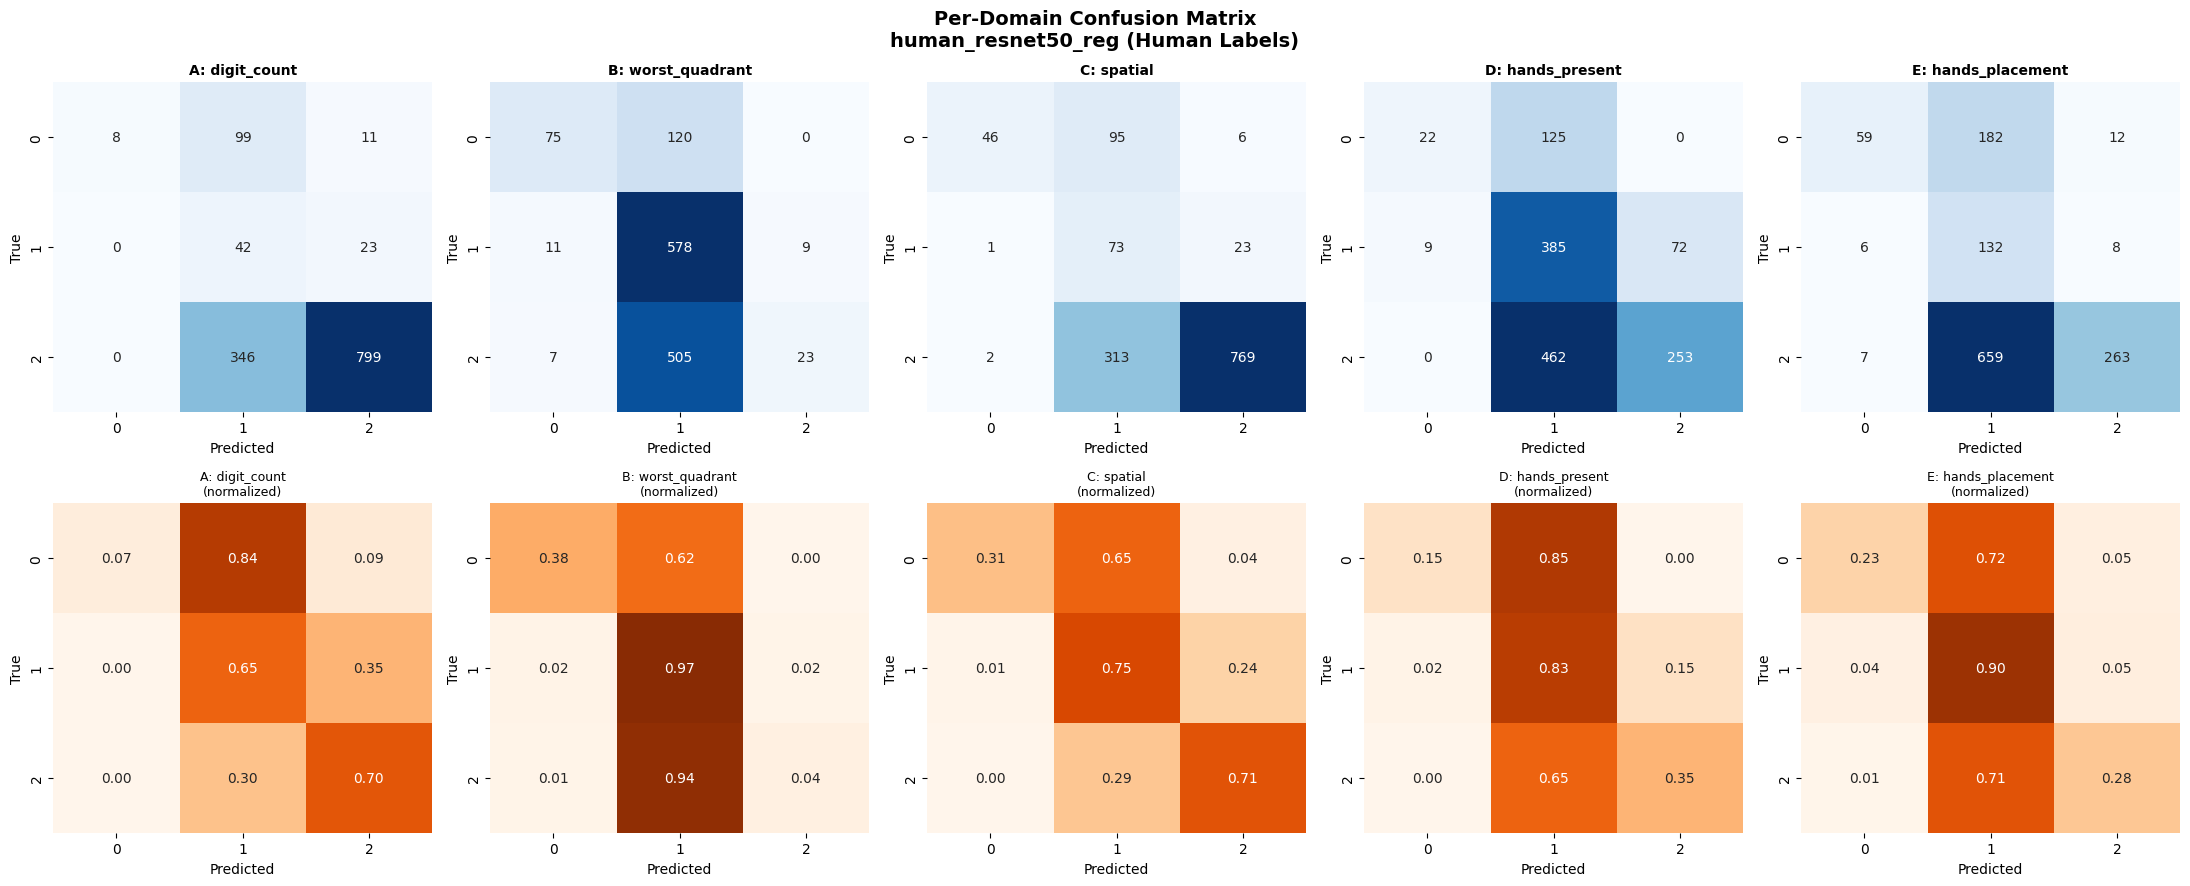

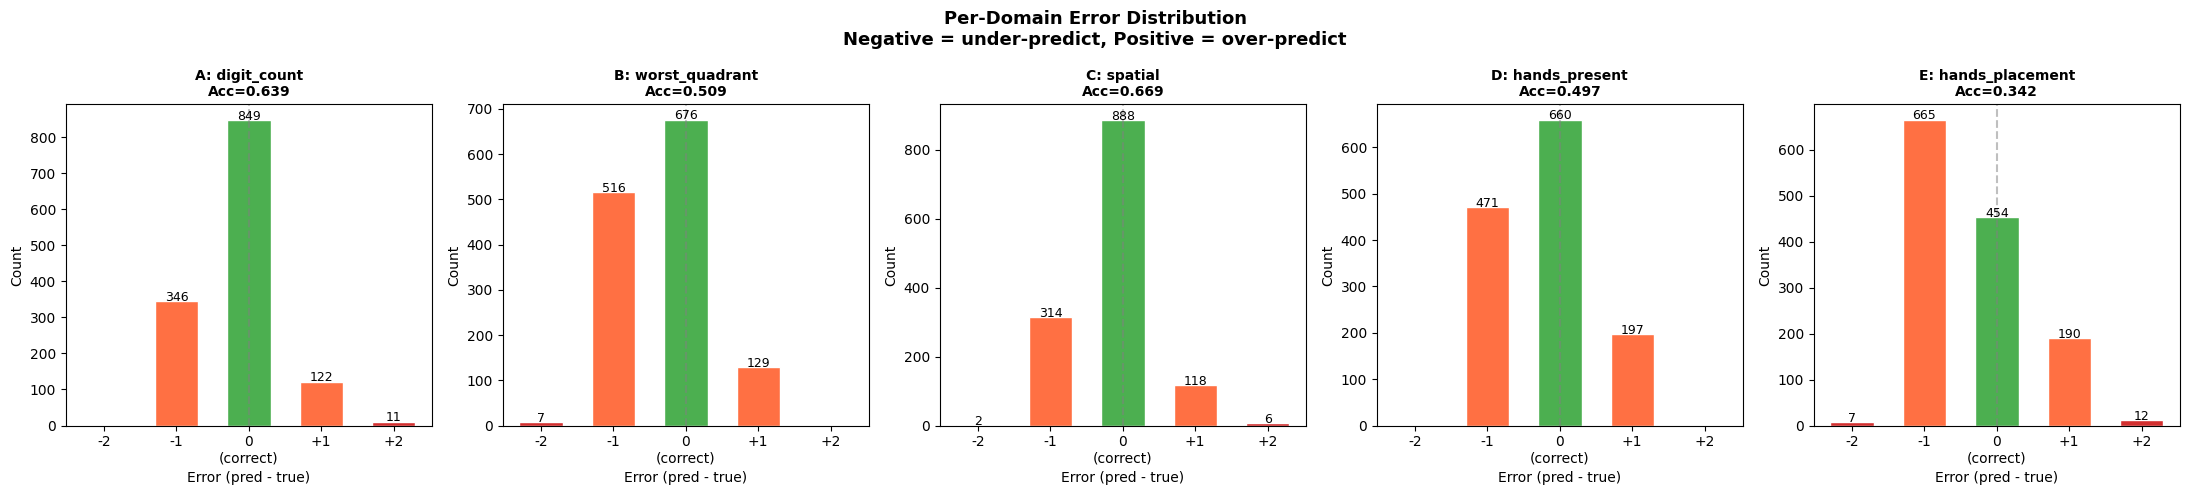

Per-Domain Error Summary
Domain                         Acc    Under   Correct     Over
-----------------------------------------------------------------
A: digit_count               0.639      346       849      133 🟡
B: worst_quadrant            0.509      523       676      129 🔴
C: spatial                   0.669      316       888      124 🟡
D: hands_present             0.497      471       660      197 🔴
E: hands_placement           0.342      672       454      202 🔴
-----------------------------------------------------------------


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

best_key = 'resnet50_reg'

test_ds = CDTDataset(
    test_df, HUMAN_FOLDER, None, val_transform
)
test_loader = DataLoader(
    test_ds, batch_size=16, shuffle=False
)

best_backbone = 'resnet50'
best_mode     = 'reg'
model_name    = f'human_{best_backbone}_{best_mode}'
path          = f'{MODEL_FOLDER}/{model_name}_best.pth'

model = CDTModel(backbone_name=best_backbone).to(device)
model.load_state_dict(
    torch.load(path, map_location=device)
)
model.eval()

all_preds  = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images  = images.to(device)
        outputs = model(images, mode=best_mode)
        preds   = get_predictions(outputs, best_mode)
        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())

all_preds  = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

domain_names = {
    0: 'A: digit_count',
    1: 'B: worst_quadrant',
    2: 'C: spatial',
    3: 'D: hands_present',
    4: 'E: hands_placement',
}

# ── Plot 1: Confusion Matrix ทุก Domain ──
fig, axes = plt.subplots(2, 5, figsize=(22, 9))

for d_idx, d_name in domain_names.items():
    true_d = all_labels[:, d_idx].astype(int)
    pred_d = all_preds[:, d_idx].astype(int)

    cm = confusion_matrix(true_d, pred_d,
                          labels=[0, 1, 2])

    cm_norm = cm.astype(float)
    row_sum = cm.sum(axis=1, keepdims=True)
    row_sum[row_sum == 0] = 1
    cm_norm = cm_norm / row_sum

    ax_raw  = axes[0][d_idx]
    ax_norm = axes[1][d_idx]

    sns.heatmap(
        cm, annot=True, fmt='d',
        cmap='Blues', ax=ax_raw,
        xticklabels=['0','1','2'],
        yticklabels=['0','1','2'],
        cbar=False
    )
    ax_raw.set_title(d_name, fontsize=10,
                     fontweight='bold')
    ax_raw.set_xlabel('Predicted')
    ax_raw.set_ylabel('True')

    sns.heatmap(
        cm_norm, annot=True, fmt='.2f',
        cmap='Oranges', ax=ax_norm,
        xticklabels=['0','1','2'],
        yticklabels=['0','1','2'],
        cbar=False,
        vmin=0, vmax=1
    )
    ax_norm.set_title(f'{d_name}\n(normalized)',
                      fontsize=9)
    ax_norm.set_xlabel('Predicted')
    ax_norm.set_ylabel('True')

plt.suptitle(
    f'Per-Domain Confusion Matrix\n'
    f'{model_name} (Human Labels)',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.savefig(
    f'{RESULT_FOLDER}/07j_confusion_matrix.png',
    dpi=150, bbox_inches='tight'
)
plt.show()

# ── Plot 2: Error Distribution ──
fig, axes = plt.subplots(1, 5, figsize=(22, 5))

for d_idx, d_name in domain_names.items():
    true_d  = all_labels[:, d_idx].astype(int)
    pred_d  = all_preds[:, d_idx].astype(int)
    errors  = pred_d - true_d

    error_counts = {e: (errors == e).sum()
                    for e in [-2, -1, 0, 1, 2]}

    colors = {
        -2: '#d32f2f', -1: '#ff7043',
         0: '#4caf50',
         1: '#ff7043',  2: '#d32f2f'
    }

    ax = axes[d_idx]
    bars = ax.bar(
        error_counts.keys(),
        error_counts.values(),
        color=[colors[e] for e in error_counts],
        edgecolor='white', width=0.6
    )

    for bar, (e, count) in zip(
        bars, error_counts.items()
    ):
        if count > 0:
            ax.text(
                bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.3,
                str(count),
                ha='center', fontsize=9
            )

    acc = (errors == 0).mean()
    ax.set_title(
        f'{d_name}\nAcc={acc:.3f}',
        fontsize=10, fontweight='bold'
    )
    ax.set_xlabel('Error (pred - true)')
    ax.set_ylabel('Count')
    ax.set_xticks([-2, -1, 0, 1, 2])
    ax.set_xticklabels(['-2', '-1', '0\n(correct)',
                        '+1', '+2'])

    ax.axvline(x=0, color='gray',
               linestyle='--', alpha=0.5)

plt.suptitle(
    f'Per-Domain Error Distribution\n'
    f'Negative = under-predict, '
    f'Positive = over-predict',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig(
    f'{RESULT_FOLDER}/07j_error_distribution.png',
    dpi=150, bbox_inches='tight'
)
plt.show()

print('='*65)
print('Per-Domain Error Summary')
print('='*65)
print(f'{"Domain":<25} {"Acc":>8} '
      f'{"Under":>8} {"Correct":>9} {"Over":>8}')
print('-'*65)

for d_idx, d_name in domain_names.items():
    true_d  = all_labels[:, d_idx].astype(int)
    pred_d  = all_preds[:, d_idx].astype(int)
    errors  = pred_d - true_d

    acc     = (errors == 0).mean()
    under   = (errors < 0).sum()
    correct = (errors == 0).sum()
    over    = (errors > 0).sum()

    difficulty = (
        '🟢' if acc >= 0.70 else
        '🟡' if acc >= 0.55 else
        '🔴'
    )

    print(f'{d_name:<25} {acc:>8.3f} '
          f'{under:>8} {correct:>9} '
          f'{over:>8} {difficulty}')

print('-'*65)